In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scvi

# Configuración
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, figsize=(8, 8))

# Cargar datos anotados
adata = sc.read_h5ad('/app/project/restore_data/pipeline_articulo/1.5cell_group_filtered/NK cells_data.h5ad')
adata

AnnData object with n_obs × n_vars = 365362 × 27629
    obs: 'dataset_id', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'cell_group', 'age_yrs', 'age_group', 'source_file', 'title', 'short_title', 'batch', 'n_genes_by_counts', 'total_counts'
    var: 'soma_joinid', 'feature_id', 'feature_name', 'feature_length', 'nnz', 'n_measured_obs', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

In [2]:
# Validar que la integración scANVI está presente en el objeto
if 'X_scANVI' in adata.obsm.keys():
    print("Integración scANVI encontrada")
else:
    print("ADVERTENCIA: Integración scANVI no encontrada, es necesario generarla")
    # Código para generar la integración scANVI (si fuera necesario)
    # Basado en la documentación que has proporcionado

ADVERTENCIA: Integración scANVI no encontrada, es necesario generarla


In [3]:
b_cell_markers = {
    'CD79A': {'effect_size': 1.97, 'specificity': 1.00, 'mean_exp': 2.63, 'pct_cells': 83.7},
    'MS4A1': {'effect_size': 1.92, 'specificity': 1.00, 'mean_exp': 2.68, 'pct_cells': 83.0},  # CD20
    'CD74': {'effect_size': 1.89, 'specificity': 0.99, 'mean_exp': 4.55, 'pct_cells': 99.3},
    'HLA-DRA': {'effect_size': 1.66, 'specificity': 0.99, 'mean_exp': 3.65, 'pct_cells': 93.1},
    'CD37': {'effect_size': 1.57, 'specificity': 1.00, 'mean_exp': 2.97, 'pct_cells': 89.5},
    'HLA-DPB1': {'effect_size': 1.45, 'specificity': 0.99, 'mean_exp': 2.79, 'pct_cells': 86.5},
    'HLA-DPA1': {'effect_size': 1.34, 'specificity': 0.98, 'mean_exp': 2.84, 'pct_cells': 84.7},
    'HLA-DQB1': {'effect_size': 1.29, 'specificity': 0.98, 'mean_exp': 2.42, 'pct_cells': 73.6},
    'LTB': {'effect_size': 1.16, 'specificity': 0.96, 'mean_exp': 2.69, 'pct_cells': 71.3},
    'HLA-DQA1': {'effect_size': 1.13, 'specificity': 0.98, 'mean_exp': 2.35, 'pct_cells': 64.9},
    'BANK1': {'effect_size': 1.12, 'specificity': 1.00, 'mean_exp': 2.38, 'pct_cells': 62.5},
    'CD79B': {'effect_size': 1.12, 'specificity': 1.00, 'mean_exp': 2.25, 'pct_cells': 60.2},
    'IGHM': {'effect_size': 1.11, 'specificity': 0.99, 'mean_exp': 2.81, 'pct_cells': 60.1},
    'CD52': {'effect_size': 1.05, 'specificity': 0.99, 'mean_exp': 2.92, 'pct_cells': 84.8},
    'HLA-DRB1': {'effect_size': 0.94, 'specificity': 0.97, 'mean_exp': 2.80, 'pct_cells': 81.4},
    'LINC00926': {'effect_size': 0.86, 'specificity': 1.00, 'mean_exp': 2.09, 'pct_cells': 45.1},
    'NCF1': {'effect_size': 0.74, 'specificity': 0.98, 'mean_exp': 2.05, 'pct_cells': 44.0},
    'LAPTM5': {'effect_size': 0.72, 'specificity': 0.98, 'mean_exp': 2.54, 'pct_cells': 82.3},
    'FCMR': {'effect_size': 0.72, 'specificity': 0.99, 'mean_exp': 2.00, 'pct_cells': 39.5},
    'TCL1A': {'effect_size': 0.71, 'specificity': 0.99, 'mean_exp': 2.40, 'pct_cells': 35.6},
    'HLA-DMA': {'effect_size': 0.68, 'specificity': 0.97, 'mean_exp': 2.05, 'pct_cells': 50.9},
    'NIBAN3': {'effect_size': 0.67, 'specificity': 1.00, 'mean_exp': 2.05, 'pct_cells': 32.9},
    'CD83': {'effect_size': 0.67, 'specificity': 0.98, 'mean_exp': 2.34, 'pct_cells': 41.8},
    'VPREB3': {'effect_size': 0.67, 'specificity': 0.99, 'mean_exp': 2.08, 'pct_cells': 32.9},
    'HLA-DMB': {'effect_size': 0.66, 'specificity': 0.97, 'mean_exp': 1.94, 'pct_cells': 38.0},
    'IGHD': {'effect_size': 0.65, 'specificity': 1.00, 'mean_exp': 2.15, 'pct_cells': 31.5},
    'IGKC': {'effect_size': 0.64, 'specificity': 0.96, 'mean_exp': 3.14, 'pct_cells': 46.2},
    'HLA-DRB5': {'effect_size': 0.64, 'specificity': 0.96, 'mean_exp': 2.51, 'pct_cells': 54.3},
    'HVCN1': {'effect_size': 0.64, 'specificity': 1.00, 'mean_exp': 1.98, 'pct_cells': 33.1},
    'RALGPS2': {'effect_size': 0.63, 'specificity': 0.97, 'mean_exp': 2.29, 'pct_cells': 52.2},
    'BLK': {'effect_size': 0.63, 'specificity': 1.00, 'mean_exp': 1.94, 'pct_cells': 29.7},
    'CD22': {'effect_size': 0.63, 'specificity': 0.99, 'mean_exp': 1.97, 'pct_cells': 30.2},
    'FCER2': {'effect_size': 0.60, 'specificity': 1.00, 'mean_exp': 2.03, 'pct_cells': 27.5},  # CD23
    'TNFRSF13C': {'effect_size': 0.58, 'specificity': 1.00, 'mean_exp': 1.89, 'pct_cells': 26.7},  # BAFF receptor
    'POU2F2': {'effect_size': 0.58, 'specificity': 0.99, 'mean_exp': 1.97, 'pct_cells': 35.9},
    'FCRL1': {'effect_size': 0.58, 'specificity': 1.00, 'mean_exp': 2.10, 'pct_cells': 27.0},
    'LIMD2': {'effect_size': 0.57, 'specificity': 0.98, 'mean_exp': 2.17, 'pct_cells': 60.7},
    'SNX2': {'effect_size': 0.56, 'specificity': 1.00, 'mean_exp': 1.95, 'pct_cells': 41.1},
    'IRF8': {'effect_size': 0.56, 'specificity': 0.98, 'mean_exp': 1.91, 'pct_cells': 32.1},
    'PTPRCAP': {'effect_size': 0.55, 'specificity': 0.90, 'mean_exp': 2.21, 'pct_cells': 31.7},
    'RIPOR2': {'effect_size': 0.54, 'specificity': 0.97, 'mean_exp': 2.15, 'pct_cells': 46.4},
    'PAX5': {'effect_size': 0.54, 'specificity': 0.99, 'mean_exp': 2.06, 'pct_cells': 24.2},
    'SP110': {'effect_size': 0.52, 'specificity': 1.00, 'mean_exp': 1.94, 'pct_cells': 35.6},
    'CD19': {'effect_size': 0.52, 'specificity': 1.00, 'mean_exp': 1.86, 'pct_cells': 22.4},
    'CXCR4': {'effect_size': 0.52, 'specificity': 0.98, 'mean_exp': 2.56, 'pct_cells': 67.3},
    'FCRLA': {'effect_size': 0.52, 'specificity': 1.00, 'mean_exp': 1.88, 'pct_cells': 22.1},
}

In [ ]:
# Marcadores canónicos adicionales (sin métricas detalladas)
    'CD44': {'effect_size': None, 'specificity': None, 'mean_exp': None, 'pct_cells': None},
    'ANLN': {'effect_size': None, 'specificity': None, 'mean_exp': None, 'pct_cells': None},
    'CDCA2': {'effect_size': None, 'specificity': None, 'mean_exp': None, 'pct_cells': None},
    'CLSPN': {'effect_size': None, 'specificity': None, 'mean_exp': None, 'pct_cells': None},
    'E2F8': {'effect_size': None, 'specificity': None, 'mean_exp': None, 'pct_cells': None},
    'FAM111B': {'effect_size': None, 'specificity': None, 'mean_exp': None, 'pct_cells': None},
    'GTSE1': {'effect_size': None, 'specificity': None, 'mean_exp': None, 'pct_cells': None},
    'JCHAIN': {'effect_size': None, 'specificity': None, 'mean_exp': None, 'pct_cells': None},
    'KIF4A': {'effect_size': None, 'specificity': None, 'mean_exp': None, 'pct_cells': None},
    'MKI67': {'effect_size': None, 'specificity': None, 'mean_exp': None, 'pct_cells': None},
    'MYBL1': {'effect_size': None, 'specificity': None, 'mean_exp': None, 'pct_cells': None},
    'NUF2': {'effect_size': None, 'specificity': None, 'mean_exp': None, 'pct_cells': None},
    'NUGGC': {'effect_size': None, 'specificity': None, 'mean_exp': None, 'pct_cells': None},
    'SDC1': {'effect_size': None, 'specificity': None, 'mean_exp': None, 'pct_cells': None},
    'TNFRSF13B': {'effect_size': None, 'specificity': None, 'mean_exp': None, 'pct_cells': None}  # TACI

In [6]:
def calculate_improved_nk_score(adata, markers_dict):
    """Calcula un score de validación NK usando todos los parámetros disponibles"""
    genes_found = [gene for gene in markers_dict.keys() if gene in adata.var_names]
    print(f"Se encontraron {len(genes_found)}/{len(markers_dict)} marcadores")
    if len(genes_found) < len(markers_dict) * 0.7:
        print(f"ADVERTENCIA: Solo se encontraron {len(genes_found)}/{len(markers_dict)} marcadores NK")
    
    # Inicializar scores
    n_cells = adata.shape[0]
    gene_scores = np.zeros((n_cells, len(genes_found)))
    weights = np.zeros(len(genes_found))
    
    for i, gene in enumerate(genes_found):
        # Obtener expresión del gen
        expr = adata[:, gene].X.toarray().flatten()
        
        # Calcular métricas observadas
        mean_expr_observed = np.mean(expr)
        pct_cells_observed = np.sum(expr > 0) / len(expr) * 100
        
        # Obtener métricas esperadas
        expected = markers_dict[gene]
        mean_expr_expected = expected['mean_exp']
        pct_cells_expected = expected['pct_cells']
        
        # Calcular ratios (qué tan cerca estamos de los valores esperados)
        mean_expr_ratio = min(mean_expr_observed / mean_expr_expected, 1.5)  # Cap at 1.5
        pct_cells_ratio = min(pct_cells_observed / pct_cells_expected, 1.5)  # Cap at 1.5
        
        # Combinar múltiples métricas para la puntuación del gen
        gene_weight = expected['effect_size'] * expected['specificity']
        gene_score = expr * gene_weight * (mean_expr_ratio * pct_cells_ratio)
        
        # Almacenar resultados
        gene_scores[:, i] = gene_score
        weights[i] = gene_weight
    
    # Calcular score final normalizado
    final_scores = np.sum(gene_scores, axis=1) / np.sum(weights) if np.sum(weights) > 0 else np.zeros(n_cells)
    
    # Calcular métricas adicionales de validación
    validation_metrics = {}
    for i, gene in enumerate(genes_found):
        expr = adata[:, gene].X.toarray().flatten()
        pct_cells_observed = np.sum(expr > 0) / len(expr) * 100
        mean_expr_observed = np.mean(expr)
        
        expected = markers_dict[gene]
        pct_threshold = expected['pct_cells'] * 0.6  # 60% del valor esperado como umbral mínimo
        exp_threshold = expected['mean_exp'] * 0.6   # 60% del valor esperado como umbral mínimo
        
        validation_metrics[gene] = {
            'passes_pct_threshold': pct_cells_observed >= pct_threshold,
            'passes_exp_threshold': mean_expr_observed >= exp_threshold,
            'pct_cells_observed': pct_cells_observed,
            'mean_expr_observed': mean_expr_observed,
            'pct_cells_expected': expected['pct_cells'],
            'mean_expr_expected': expected['mean_exp']
        }
    
    return final_scores, validation_metrics

In [7]:
calculate_improved_nk_score(adata, b_cell_markers)

Se encontraron 46/46 marcadores


(array([0.05391661, 0.20968555, 0.07286465, ..., 0.4626227 , 0.1878348 ,
        0.41003167]),
 {'CD79A': {'passes_pct_threshold': False,
   'passes_exp_threshold': False,
   'pct_cells_observed': 2.7140206151707074,
   'mean_expr_observed': 0.08087321615274713,
   'pct_cells_expected': 83.7,
   'mean_expr_expected': 2.63},
  'MS4A1': {'passes_pct_threshold': False,
   'passes_exp_threshold': False,
   'pct_cells_observed': 2.1203628182460137,
   'mean_expr_observed': 0.10296089905354142,
   'pct_cells_expected': 83.0,
   'mean_expr_expected': 2.68},
  'CD74': {'passes_pct_threshold': True,
   'passes_exp_threshold': True,
   'pct_cells_observed': 74.56330981328108,
   'mean_expr_observed': 4.565767649618734,
   'pct_cells_expected': 99.3,
   'mean_expr_expected': 4.55},
  'HLA-DRA': {'passes_pct_threshold': False,
   'passes_exp_threshold': False,
   'pct_cells_observed': 17.76238360858546,
   'mean_expr_observed': 0.6140759028032472,
   'pct_cells_expected': 93.1,
   'mean_expr_expec

In [13]:
import pandas as pd

def check_marker(expression, threshold):
    return expression >= threshold

def validate_b_cells(adata, markers, thresholds, min_markers):
    marker_genes = list(markers.keys())
    
    # Check if all marker genes are in the dataset
    missing_markers = set(marker_genes) - set(adata.var_names)
    if missing_markers:
        print(f"Warning: Markers {missing_markers} not found in dataset.")
    
    # Filter marker genes to those present in dataset
    marker_genes = [gene for gene in marker_genes if gene in adata.var_names]
    
    # Compute number of markers expressed per cell
    markers_expressed = pd.DataFrame(
        {gene: adata[:, gene].X.toarray().flatten() > thresholds[gene] for gene in marker_genes}
    ).sum(axis=1)
    
    # Compute weighted count based on marker specificity
    weighted_markers = markers_expressed.copy()
    for gene in marker_genes:
        weighted_markers[adata[:, gene].X.toarray().flatten() > thresholds[gene]] += markers[gene] - 1
    
    # Determine if each cell meets minimum marker cutoff 
    is_b_cell = weighted_markers >= min_markers
    
    return is_b_cell

# Example usage
canonical_markers = {
    'CD19': 2, # Very specific, counts twice
    'MS4A1': 2, # Very specific, counts twice 
    'CD79A': 1,
    'CD79B': 1,
    'IGHM': 1,
}

marker_thresholds = {
    'CD19': 1.5,
    'MS4A1': 2,
    'CD79A': 2,  
    'CD79B': 1.8,
    'IGHM': 2.5,
}

adata.obs['is_b_cell'] = validate_b_cells(adata, canonical_markers, marker_thresholds, min_markers=3)



# Handle NaN values in the 'is_b_cell' column
is_b_cell = adata.obs['is_b_cell'].fillna(False)

# Additional B cell markers for validation
additional_markers = ['CD20', 'CD22', 'CD24', 'CD38', 'CD40']



# Handle NaN values in the 'is_b_cell' column
is_b_cell = adata.obs['is_b_cell'].fillna(False)

# Additional B cell markers for validation
additional_markers = ['CD20', 'CD22', 'CD24', 'CD38', 'CD40']

print("Expression of additional markers in predicted B cells:")
for marker in additional_markers:
    if marker in adata.var_names:
        b_cell_exp = adata[is_b_cell, marker].X.toarray().flatten()
        other_exp = adata[~is_b_cell, marker].X.toarray().flatten()
        
        print(f"{marker}:")
        if len(b_cell_exp) > 0:
            print(f"  B cells: mean={b_cell_exp.mean():.2f}, min={b_cell_exp.min():.2f}, max={b_cell_exp.max():.2f}")
        else:
            print("  No cells predicted as B cells.")
        
        if len(other_exp) > 0:
            print(f"  Other cells: mean={other_exp.mean():.2f}, min={other_exp.min():.2f}, max={other_exp.max():.2f}")
        else:
            print("  All cells predicted as B cells.")
    else:
        print(f"{marker} not found in dataset.")

/tmp/ipykernel_23315/316686904.py:54: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  is_b_cell = adata.obs['is_b_cell'].fillna(False)
/tmp/ipykernel_23315/316686904.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  is_b_cell = adata.obs['is_b_cell'].fillna(False)


Expression of additional markers in predicted B cells:
CD20 not found in dataset.
CD22:
  No cells predicted as B cells.
  Other cells: mean=0.01, min=0.00, max=9.00
CD24:
  No cells predicted as B cells.
  Other cells: mean=0.01, min=0.00, max=35.00
CD38:
  No cells predicted as B cells.
  Other cells: mean=0.40, min=0.00, max=2410.00
CD40:
  No cells predicted as B cells.
  Other cells: mean=0.03, min=0.00, max=902.00


In [22]:
import pandas as pd

def validate_B_cells(adata, markers, min_markers):
    marker_genes = list(markers.keys())
    
    # Check if all marker genes are in the dataset
    missing_markers = set(marker_genes) - set(adata.var_names)
    if missing_markers:
        print(f"Warning: Markers {missing_markers} not found in dataset.")
    
    # Filter marker genes to those present in dataset
    marker_genes = [gene for gene in marker_genes if gene in adata.var_names]
    
    # Compute number of markers expressed per cell
    markers_expressed = pd.DataFrame(
        {gene: adata[:, gene].X.toarray().flatten() > 0 for gene in marker_genes}
    )
    
    # Add a new column for the total number of markers expressed
    markers_expressed['total_expressed'] = markers_expressed.sum(axis=1)
    
    # Determine if each cell meets minimum marker cutoff 
    is_B_cell = markers_expressed['total_expressed'] >= min_markers
    
    return is_B_cell, markers_expressed

# B cell canonical markers
canonical_markers = {
    'CD44': 1,
    'ANLN': 1,
    'CDCA2': 1,
    'CLSPN': 1,
    'E2F8': 1,
    'FAM111B': 1,
    'GTSE1': 1,
    'JCHAIN': 1,
    'KIF4A': 1,
    'MKI67': 1,
    'MYBL1': 1,
    'NUF2': 1,
    'NUGGC': 1,
    'SDC1': 1,
    'TNFRSF13B': 1
}

is_B_cell, markers_expressed = validate_B_cells(adata, canonical_markers, min_markers=2)

adata.obs['is_B_cell'] = is_B_cell

# Print the number of cells predicted as B cells
print(f"Number of cells predicted as B cells: {is_B_cell.sum()}")

# Print the percentage of cells expressing each marker
for marker in canonical_markers:
    if marker in adata.var_names:
        pct_expressed = (markers_expressed[marker].sum() / len(markers_expressed)) * 100
        print(f"Percentage of cells expressing {marker}: {pct_expressed:.2f}%")
    else:
        print(f"{marker} not found in dataset.")



Number of cells predicted as B cells: 85964
Percentage of cells expressing CD44: 41.45%
Percentage of cells expressing ANLN: 0.17%
Percentage of cells expressing CDCA2: 0.26%
Percentage of cells expressing CLSPN: 1.20%
Percentage of cells expressing E2F8: 0.08%
Percentage of cells expressing FAM111B: 0.31%
Percentage of cells expressing GTSE1: 0.62%
Percentage of cells expressing JCHAIN: 3.37%
Percentage of cells expressing KIF4A: 0.30%
Percentage of cells expressing MKI67: 0.99%
Percentage of cells expressing MYBL1: 42.50%
Percentage of cells expressing NUF2: 1.25%
Percentage of cells expressing NUGGC: 1.41%
Percentage of cells expressing SDC1: 0.01%
Percentage of cells expressing TNFRSF13B: 0.45%


Number of cells predicted as B cells: 85964
Percentage of cells expressing CD44: 41.45%
Percentage of cells expressing ANLN: 0.17%
Percentage of cells expressing CDCA2: 0.26%
Percentage of cells expressing CLSPN: 1.20%
Percentage of cells expressing E2F8: 0.08%
Percentage of cells expressing FAM111B: 0.31%
Percentage of cells expressing GTSE1: 0.62%
Percentage of cells expressing JCHAIN: 3.37%
Percentage of cells expressing KIF4A: 0.30%
Percentage of cells expressing MKI67: 0.99%
Percentage of cells expressing MYBL1: 42.50%
Percentage of cells expressing NUF2: 1.25%
Percentage of cells expressing NUGGC: 1.41%
Percentage of cells expressing SDC1: 0.01%
Percentage of cells expressing TNFRSF13B: 0.45%


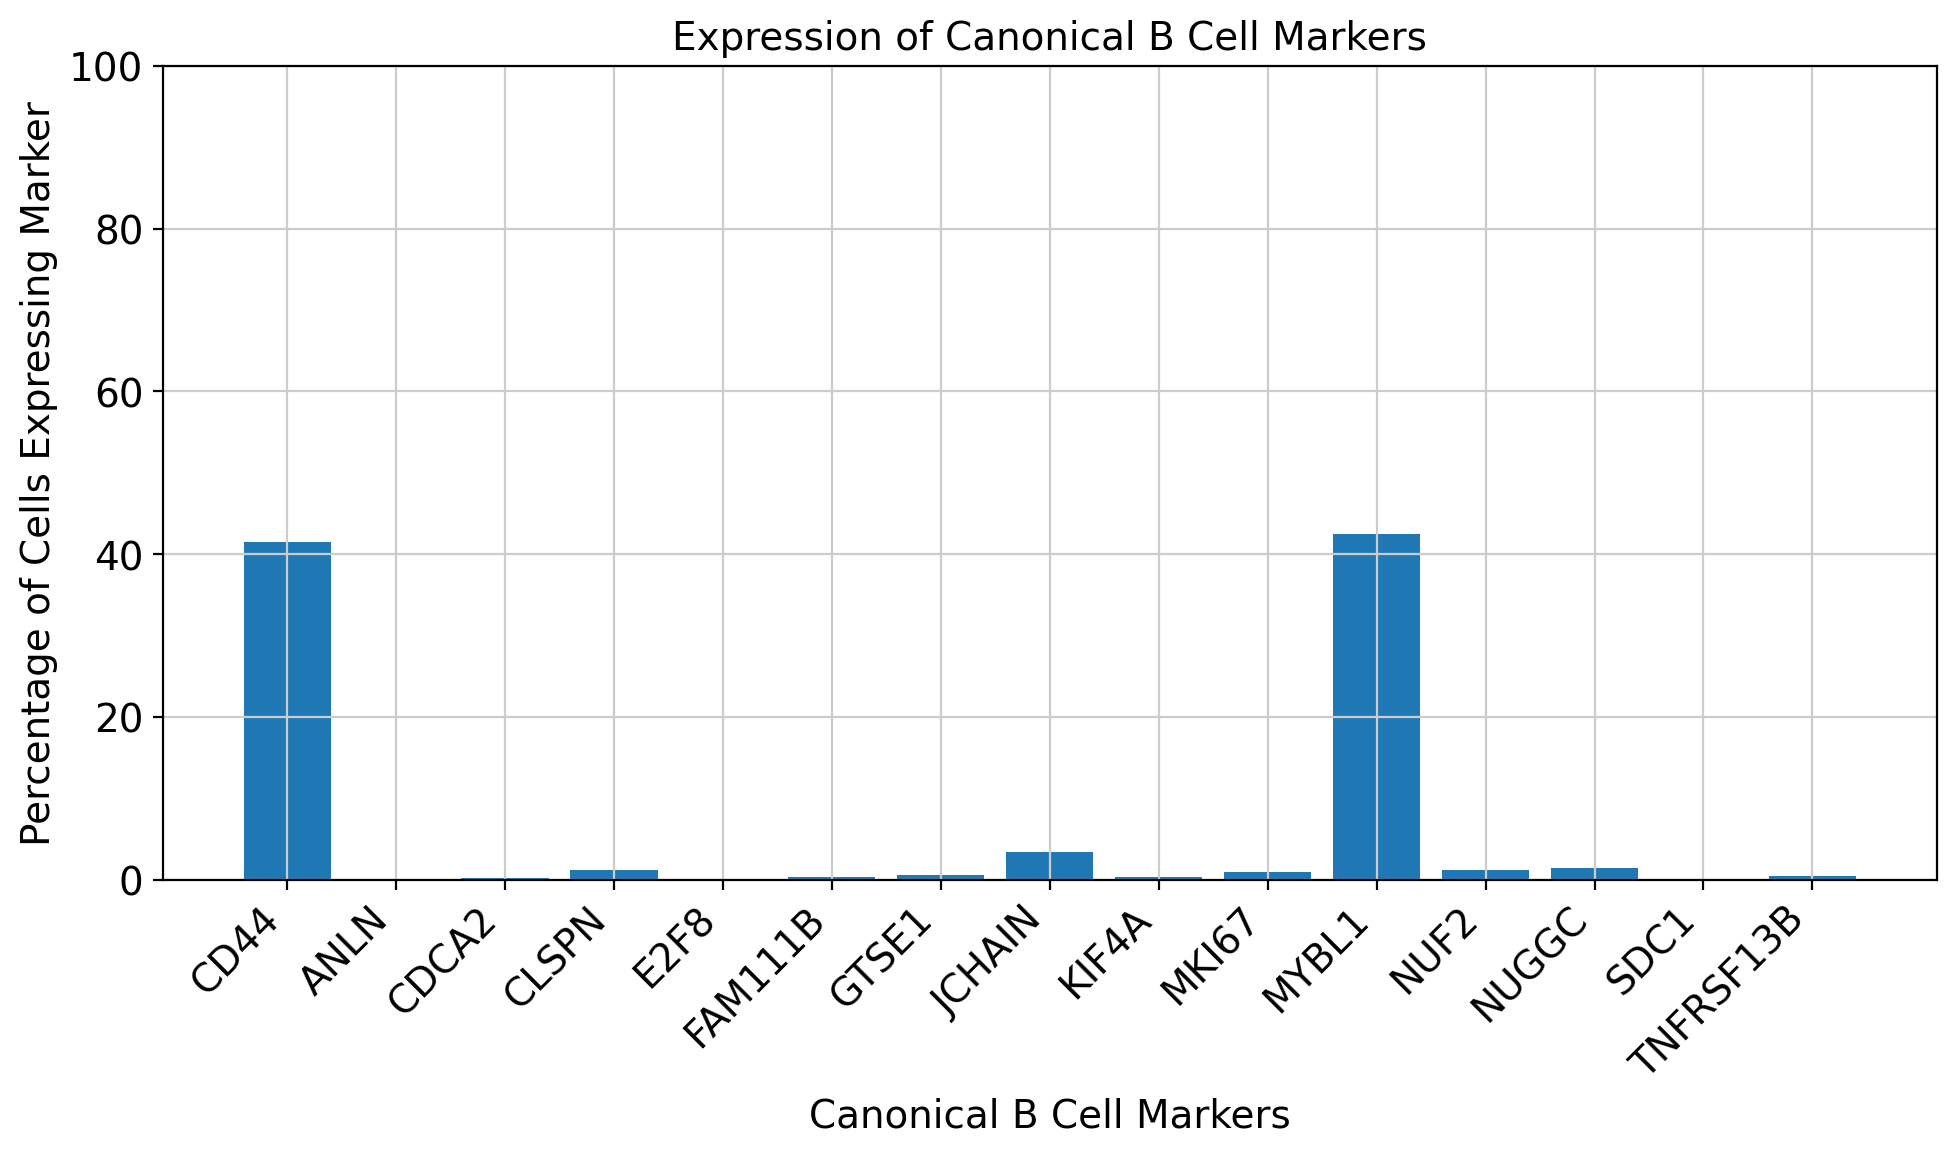

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

def validate_B_cells(adata, markers, min_markers):
    marker_genes = list(markers.keys())
    
    # Check if all marker genes are in the dataset
    missing_markers = set(marker_genes) - set(adata.var_names)
    if missing_markers:
        print(f"Warning: Markers {missing_markers} not found in dataset.")
    
    # Filter marker genes to those present in dataset
    marker_genes = [gene for gene in marker_genes if gene in adata.var_names]
    
    # Compute number of markers expressed per cell
    markers_expressed = pd.DataFrame(
        {gene: adata[:, gene].X.toarray().flatten() > 0 for gene in marker_genes}
    )
    
    # Add a new column for the total number of markers expressed
    markers_expressed['total_expressed'] = markers_expressed.sum(axis=1)
    
    # Determine if each cell meets minimum marker cutoff 
    is_B_cell = markers_expressed['total_expressed'] >= min_markers
    
    return is_B_cell, markers_expressed

# B cell canonical markers
canonical_markers = {
    'CD44': 1,
    'ANLN': 1,
    'CDCA2': 1,
    'CLSPN': 1,
    'E2F8': 1,
    'FAM111B': 1,
    'GTSE1': 1,
    'JCHAIN': 1,
    'KIF4A': 1,
    'MKI67': 1,
    'MYBL1': 1,
    'NUF2': 1,
    'NUGGC': 1,
    'SDC1': 1,
    'TNFRSF13B': 1
}

is_B_cell, markers_expressed = validate_B_cells(adata, canonical_markers, min_markers=2)

adata.obs['is_B_cell'] = is_B_cell

# Print the number of cells predicted as B cells
print(f"Number of cells predicted as B cells: {is_B_cell.sum()}")

# Create lists to store marker names and percentages
marker_names = []
marker_percentages = []

# Print the percentage of cells expressing each marker and store the values
for marker in canonical_markers:
    if marker in adata.var_names:
        pct_expressed = (markers_expressed[marker].sum() / len(markers_expressed)) * 100
        print(f"Percentage of cells expressing {marker}: {pct_expressed:.2f}%")
        marker_names.append(marker)
        marker_percentages.append(pct_expressed)
    else:
        print(f"{marker} not found in dataset.")


# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(marker_names, marker_percentages)
plt.xlabel('Canonical B Cell Markers')
plt.ylabel('Percentage of Cells Expressing Marker')
plt.title('Expression of Canonical B Cell Markers')
plt.ylim(0, 100)  # Set y-axis limits from 0 to 100
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [23]:
adata_old = adata[adata.obs['age_group'] == 'old']

is_B_cell_old, markers_expressed_old = validate_B_cells(adata_old, canonical_markers, min_markers=2)

adata.obs['is_B_cell'] = is_B_cell_old

# Print the number of cells predicted as B cells
print(f"Number of cells predicted as B cells: {is_B_cell_old.sum()}")

# Print the percentage of cells expressing each marker
for marker in canonical_markers:
    if marker in adata_old.var_names:
        pct_expressed = (markers_expressed_old[marker].sum() / len(markers_expressed_old)) * 100
        print(f"Percentage of cells expressing {marker}: {pct_expressed:.2f}%")
    else:
        print(f"{marker} not found in dataset.")

Number of cells predicted as B cells: 11548
Percentage of cells expressing CD44: 41.03%
Percentage of cells expressing ANLN: 0.09%
Percentage of cells expressing CDCA2: 0.12%
Percentage of cells expressing CLSPN: 1.07%
Percentage of cells expressing E2F8: 0.04%
Percentage of cells expressing FAM111B: 0.13%
Percentage of cells expressing GTSE1: 0.44%
Percentage of cells expressing JCHAIN: 2.67%
Percentage of cells expressing KIF4A: 0.09%
Percentage of cells expressing MKI67: 1.02%
Percentage of cells expressing MYBL1: 35.13%
Percentage of cells expressing NUF2: 1.11%
Percentage of cells expressing NUGGC: 0.92%
Percentage of cells expressing SDC1: 0.01%
Percentage of cells expressing TNFRSF13B: 0.10%


In [24]:
adata_young = adata[adata.obs['age_group'] == 'young']

is_B_cell_young, markers_expressed_young = validate_B_cells(adata_young, canonical_markers, min_markers=2)

adata.obs['is_B_cell'] = is_B_cell_young

# Print the number of cells predicted as B cells
print(f"Number of cells predicted as B cells: {is_B_cell_young.sum()}")

# Print the percentage of cells expressing each marker
for marker in canonical_markers:
    if marker in adata_young.var_names:
        pct_expressed = (markers_expressed_young[marker].sum() / len(markers_expressed_young)) * 100
        print(f"Percentage of cells expressing {marker}: {pct_expressed:.2f}%")
    else:
        print(f"{marker} not found in dataset.")

Number of cells predicted as B cells: 41803
Percentage of cells expressing CD44: 39.42%
Percentage of cells expressing ANLN: 0.27%
Percentage of cells expressing CDCA2: 0.38%
Percentage of cells expressing CLSPN: 1.34%
Percentage of cells expressing E2F8: 0.14%
Percentage of cells expressing FAM111B: 0.47%
Percentage of cells expressing GTSE1: 0.84%
Percentage of cells expressing JCHAIN: 4.21%
Percentage of cells expressing KIF4A: 0.56%
Percentage of cells expressing MKI67: 1.15%
Percentage of cells expressing MYBL1: 47.03%
Percentage of cells expressing NUF2: 1.39%
Percentage of cells expressing NUGGC: 1.78%
Percentage of cells expressing SDC1: 0.02%
Percentage of cells expressing TNFRSF13B: 0.72%


Percentage of cells expressing NCAM1: 28.91%
Percentage of cells expressing FCGR3A: 73.67%
NKG2D not found in dataset.
Percentage of cells expressing KLRK1: 48.66%
Percentage of cells expressing NCR1: 32.49%
Percentage of cells expressing KLRB1: 67.71%
Percentage of cells expressing KLRD1: 82.52%
Percentage of cells expressing GZMA: 78.65%
Percentage of cells expressing GZMB: 79.87%
Percentage of cells expressing PRF1: 86.90%
Percentage of cells expressing GNLY: 93.16%
Percentage of cells expressing GZMH: 60.80%


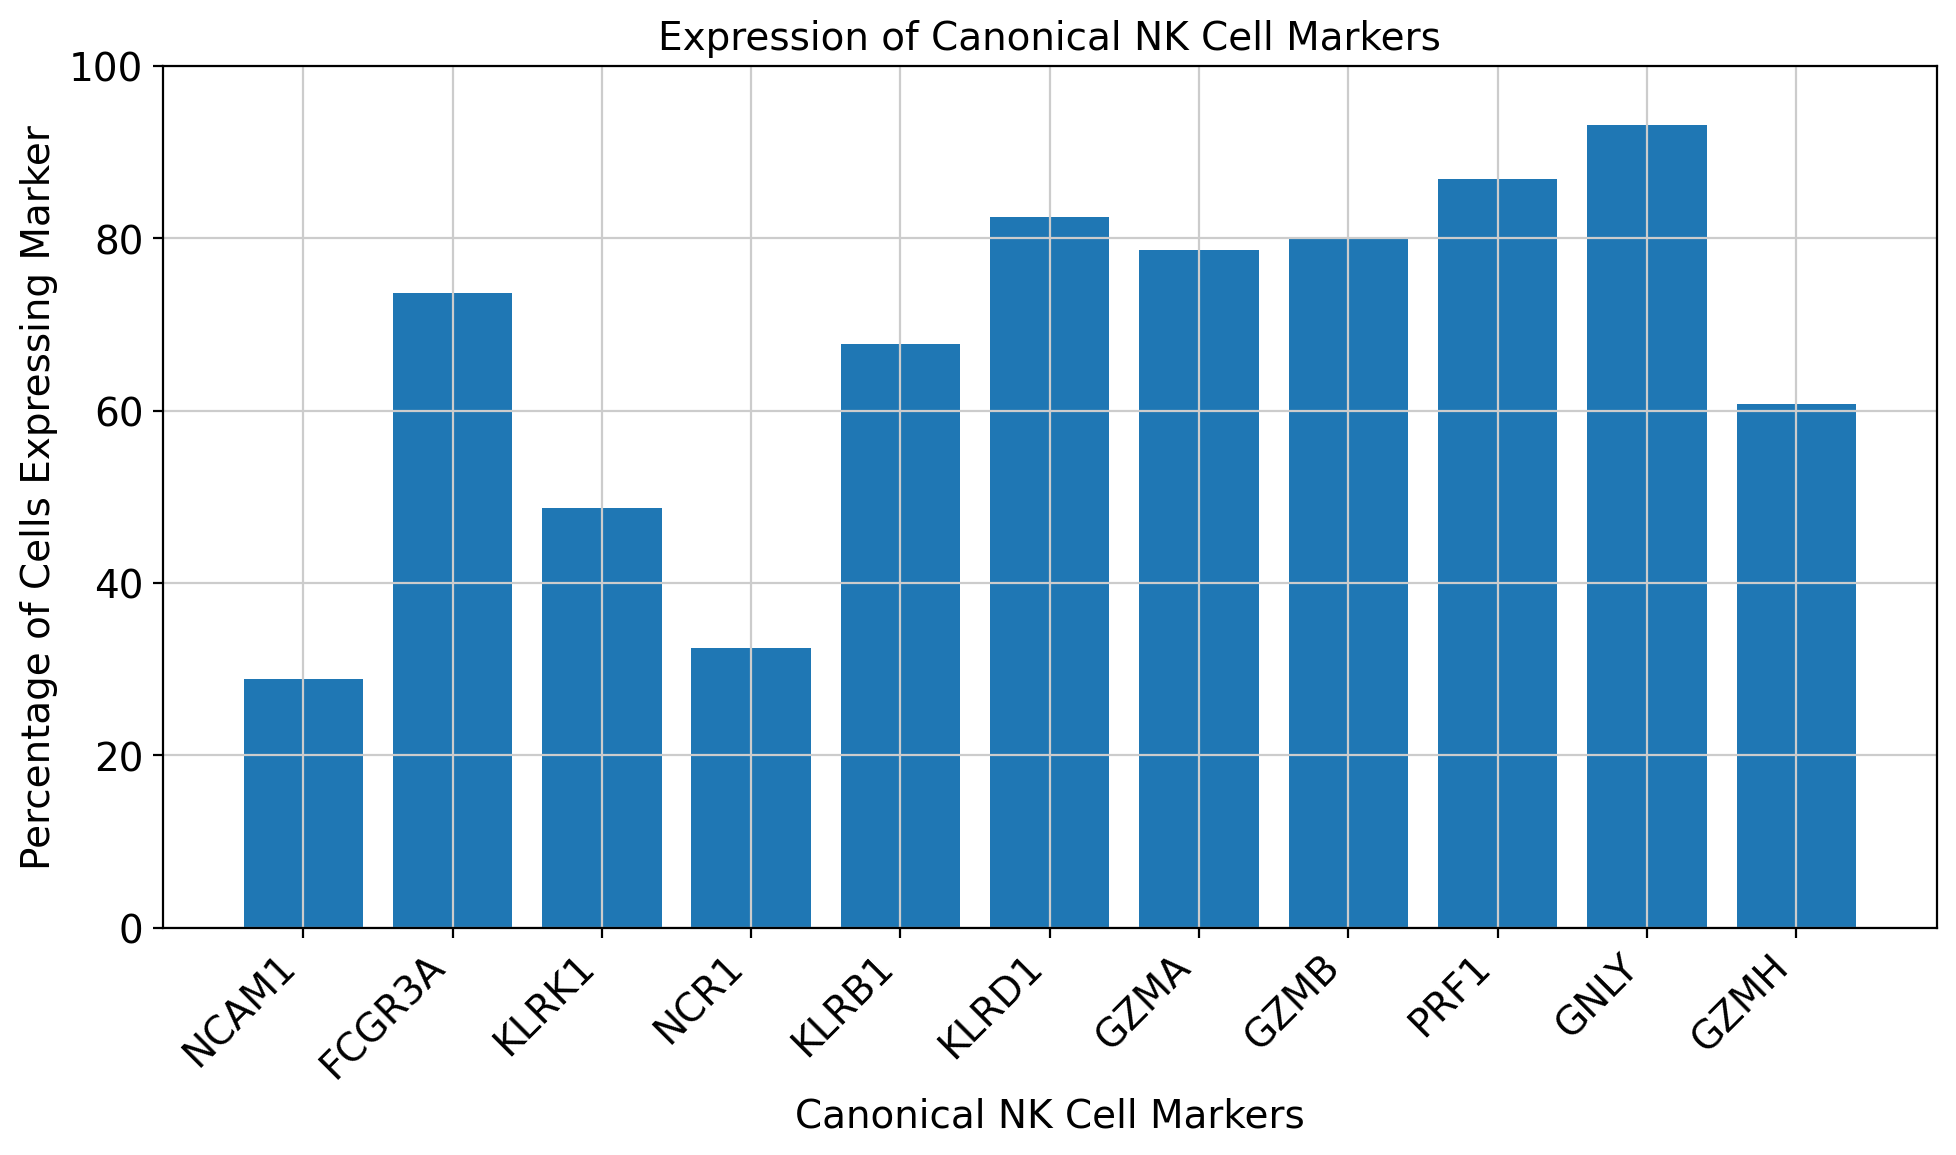

In [29]:
import pandas as pd

def validate_nk_cells(adata, markers, min_markers):
    marker_genes = list(markers.keys())
    
    # Check if all marker genes are in the dataset
    missing_markers = set(marker_genes) - set(adata.var_names)
    if missing_markers:
        print(f"Warning: Markers {missing_markers} not found in dataset.")
    
    # Filter marker genes to those present in dataset
    marker_genes = [gene for gene in marker_genes if gene in adata.var_names]
    
    # Compute number of markers expressed per cell
    markers_expressed = pd.DataFrame(
        {gene: adata[:, gene].X.toarray().flatten() > 0 for gene in marker_genes}
    )
    
    # Add a new column for the total number of markers expressed
    markers_expressed['total_expressed'] = markers_expressed.sum(axis=1)
    
    # Determine if each cell meets minimum marker cutoff 
    is_nk_cell = markers_expressed['total_expressed'] >= min_markers
    
    return is_nk_cell, markers_expressed

# NK cell canonical markers
canonical_markers = {
    'NCAM1': 1,  # CD56
    'FCGR3A': 1, # CD16a
    'NKG2D': 1,  # CD314
    'KLRK1': 1,
    'NCR1': 1,   # NKp46
    'KLRB1': 1,  # CD161
    'KLRD1': 1,  # CD94
    'GZMA': 1,
    'GZMB': 1, 
    'PRF1': 1, 
    'GNLY': 1, 
    'GZMH': 1
}

is_nk_cell, markers_expressed = validate_nk_cells(adata, canonical_markers, min_markers=2)

adata.obs['is_nk_cell'] = is_nk_cell



# Create lists to store marker names and percentages
marker_names = []
marker_percentages = []

# Print the percentage of cells expressing each marker and store the values
for marker in canonical_markers:
    if marker in adata.var_names:
        pct_expressed = (markers_expressed[marker].sum() / len(markers_expressed)) * 100
        print(f"Percentage of cells expressing {marker}: {pct_expressed:.2f}%")
        marker_names.append(marker)
        marker_percentages.append(pct_expressed)
    else:
        print(f"{marker} not found in dataset.")

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(marker_names, marker_percentages)
plt.xlabel('Canonical NK Cell Markers')
plt.ylabel('Percentage of Cells Expressing Marker')
plt.title('Expression of Canonical NK Cell Markers')
plt.ylim(0, 100)  # Set y-axis limits from 0 to 100
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Percentage of cells expressing NCAM1: 28.91%
Percentage of cells expressing FCGR3A: 73.67%
NKG2D not found in dataset.
Percentage of cells expressing KLRK1: 48.66%
Percentage of cells expressing NCR1: 32.49%
Percentage of cells expressing KLRB1: 67.71%
Percentage of cells expressing KLRD1: 82.52%
Percentage of cells expressing GZMA: 78.65%
Percentage of cells expressing GZMB: 79.87%
Percentage of cells expressing PRF1: 86.90%
Percentage of cells expressing GNLY: 93.16%
Percentage of cells expressing GZMH: 60.80%
Percentage of cells expressing KLRF1: 71.68%
Percentage of cells expressing NKG7: 91.01%
Percentage of cells expressing PTPRC: 92.74%
Percentage of cells expressing RUNX3: 53.22%
Percentage of cells expressing TBX21: 49.34%
Percentage of cells expressing TYROBP: 80.47%
Percentage of cells expressing XCL2: 29.26%
Percentage of cells expressing CD53: 66.72%
Percentage of cells expressing CMC1: 53.37%
Percentage of cells expressing CORO1A: 80.97%
Percentage of cells expressing EOM

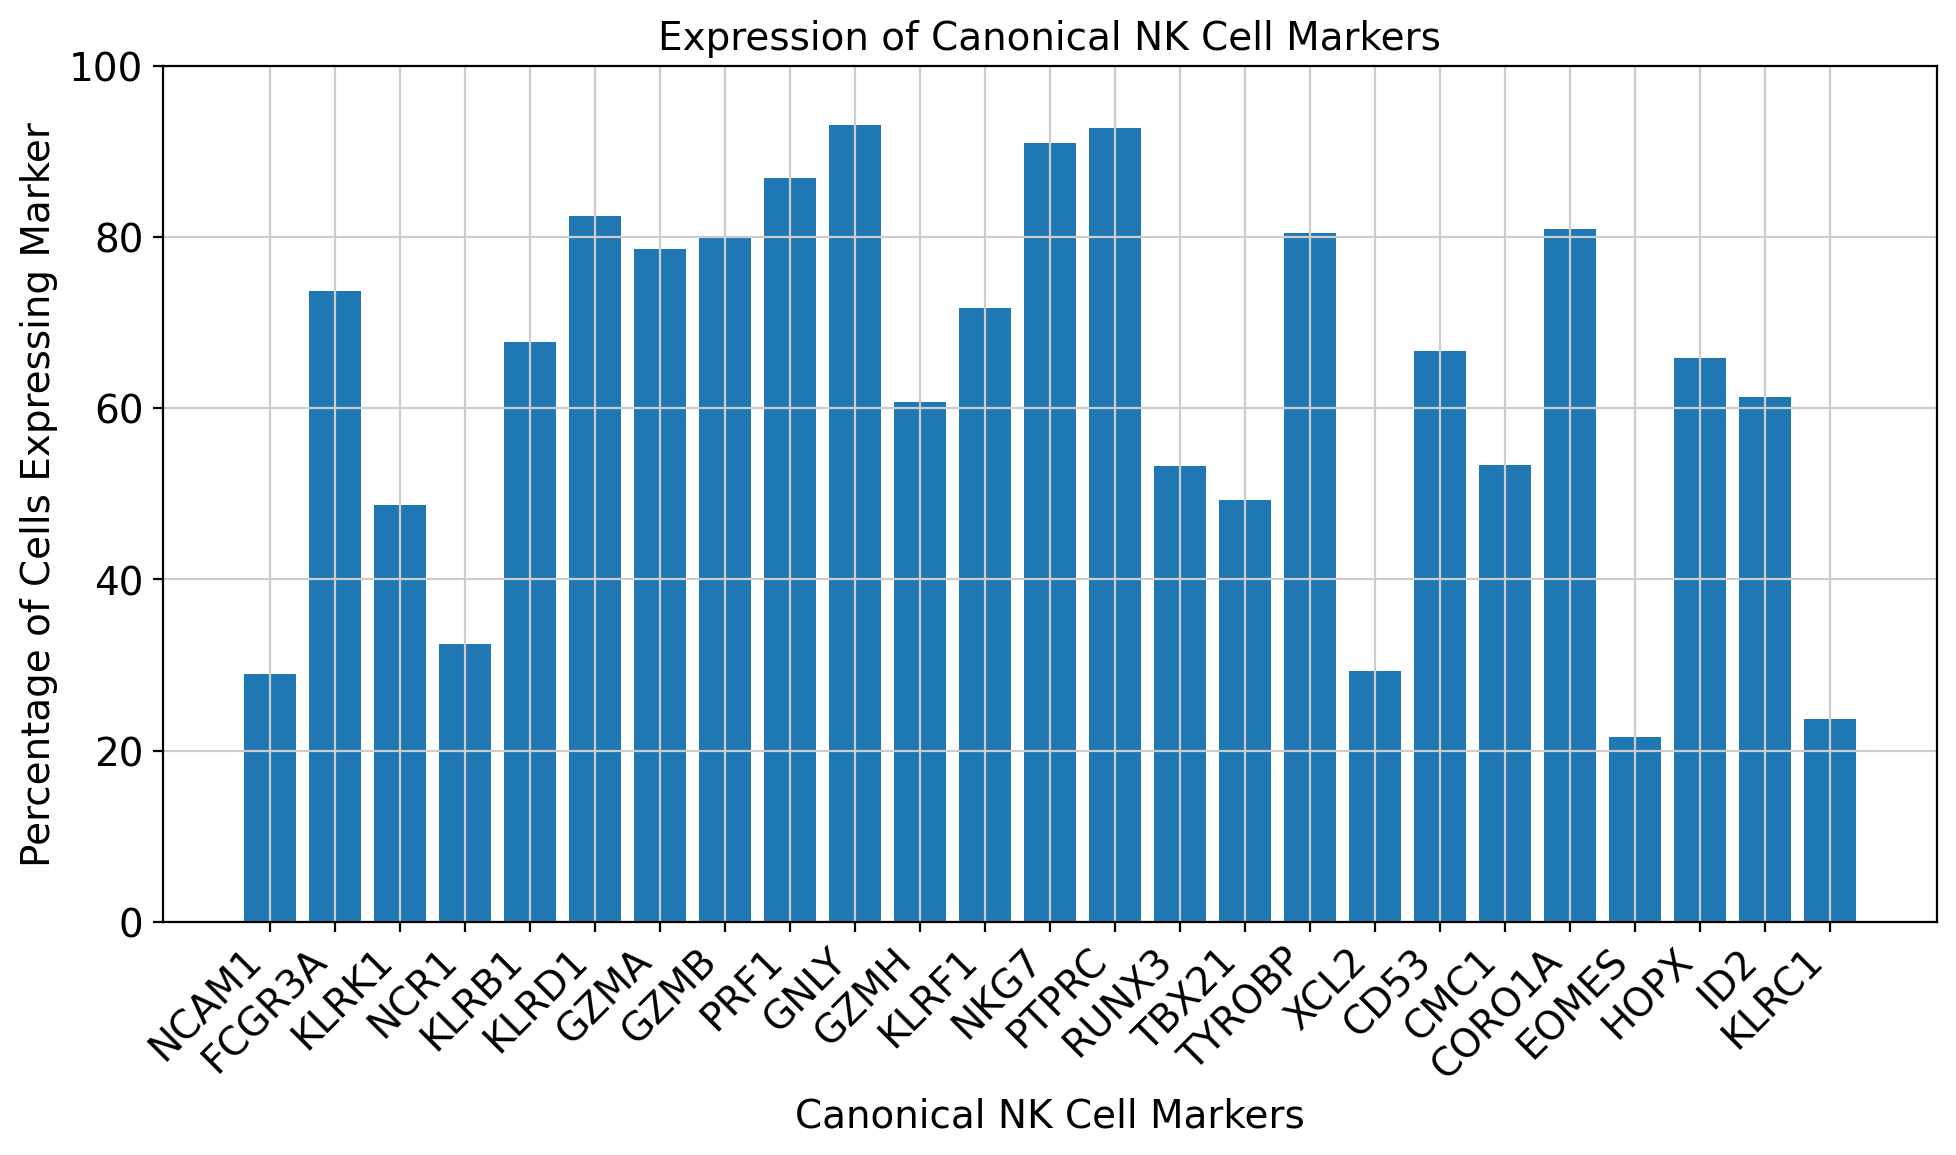

In [2]:
import pandas as pd

def validate_nk_cells(adata, markers, min_markers):
    marker_genes = list(markers.keys())
    
    # Check if all marker genes are in the dataset
    missing_markers = set(marker_genes) - set(adata.var_names)
    if missing_markers:
        print(f"Warning: Markers {missing_markers} not found in dataset.")
    
    # Filter marker genes to those present in dataset
    marker_genes = [gene for gene in marker_genes if gene in adata.var_names]
    
    # Compute number of markers expressed per cell
    markers_expressed = pd.DataFrame(
        {gene: adata[:, gene].X.toarray().flatten() > 0 for gene in marker_genes}
    )
    
    # Add a new column for the total number of markers expressed
    markers_expressed['total_expressed'] = markers_expressed.sum(axis=1)
    
    # Determine if each cell meets minimum marker cutoff 
    is_nk_cell = markers_expressed['total_expressed'] >= min_markers
    
    return is_nk_cell, markers_expressed

# NK cell canonical markers
canonical_markers = {
    'NCAM1': 1,  # CD56
    'FCGR3A': 1, # CD16a
    'NKG2D': 1,  # CD314
    'KLRK1': 1,
    'NCR1': 1,   # NKp46
    'KLRB1': 1,  # CD161
    'KLRD1': 1,  # CD94
    'GZMA': 1,   # granzyme A
    'GZMB': 1, 
    'PRF1': 1, 
    'GNLY': 1,   # granulysin
    'GZMH': 1,
    # Genes adicionales de las imágenes
    'KLRF1': 1,
    'NKG7': 1,   # natural killer cell granule protein 7
    'PTPRC': 1,  # protein tyrosine phosphatase receptor type C
    'RUNX3': 1,  # RUNX family transcription factor 3
    'TBX21': 1,  # T-box transcription factor 21 (T-bet)
    'TYROBP': 1,
    'XCL2': 1,
    'CD53': 1,   # CD53 molecule
    'CMC1': 1,
    'CORO1A': 1, # coronin 1A
    'EOMES': 1,  # eomesodermin
    'HOPX': 1,
    'ID2': 1,    # inhibitor of DNA binding 2
    'KLRC1': 1   # killer cell lectin like receptor C1
}

is_nk_cell, markers_expressed = validate_nk_cells(adata, canonical_markers, min_markers=2)

adata.obs['is_nk_cell'] = is_nk_cell



# Create lists to store marker names and percentages
marker_names = []
marker_percentages = []

# Print the percentage of cells expressing each marker and store the values
for marker in canonical_markers:
    if marker in adata.var_names:
        pct_expressed = (markers_expressed[marker].sum() / len(markers_expressed)) * 100
        print(f"Percentage of cells expressing {marker}: {pct_expressed:.2f}%")
        marker_names.append(marker)
        marker_percentages.append(pct_expressed)
    else:
        print(f"{marker} not found in dataset.")

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(marker_names, marker_percentages)
plt.xlabel('Canonical NK Cell Markers')
plt.ylabel('Percentage of Cells Expressing Marker')
plt.title('Expression of Canonical NK Cell Markers')
plt.ylim(0, 100)  # Set y-axis limits from 0 to 100
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
adata.obs['is_b_cell'].value_counts()

Series([], Name: count, dtype: int64)

In [7]:
def calculate_nk_validation_score(adata, nk_markers):
    """
    Calcula un score de validación ponderado para células NK basado en DWLS
    
    Parameters:
    -----------
    adata : AnnData
        Objeto AnnData conteniendo los datos de expresión
    nk_markers : dict
        Diccionario con genes marcadores NK y sus métricas
        
    Returns:
    --------
    numpy.ndarray
        Array con los scores de validación NK para cada célula
    """
    genes_found = [gene for gene in nk_markers.keys() if gene in adata.var_names]
    
    # Inicializar score
    scores = np.zeros(adata.shape[0])
    weights_sum = 0
    
    for gene in genes_found:
        # Ponderación basada en DWLS: Effect Size × Specificity
        weight = nk_markers[gene]['effect_size'] * nk_markers[gene]['specificity']
        
        # Obtener expresión y multiplicar por peso
        expr = adata[:, gene].X.toarray().flatten()
        scores += expr * weight
        weights_sum += weight
    
    # Normalizar por la suma de pesos
    if weights_sum > 0:
        scores = scores / weights_sum
    
    return scores

calculate_nk_validation_score(adata, nk_markers)


array([0.11211807, 0.3496823 , 0.23146343, ..., 0.77467281, 0.41622408,
       0.7480318 ])

In [8]:
scores= calculate_nk_validation_score(adata, nk_markers)
lista_scores = scores.tolist()
print(lista_scores)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [9]:
print(scores.min())
print(scores.max())

0.0
349.18319368149247


computing score 'nk_cytotoxic_score'
    finished: added
    'nk_cytotoxic_score', score of gene set (adata.obs).
    11 total control genes are used. (0:00:12)
computing score 'nk_receptor_score'
    finished: added
    'nk_receptor_score', score of gene set (adata.obs).
    6 total control genes are used. (0:00:11)
computing score 'nk_signaling_score'
    finished: added
    'nk_signaling_score', score of gene set (adata.obs).
    4 total control genes are used. (0:00:11)
computing score 'nk_score'
    finished: added
    'nk_score', score of gene set (adata.obs).
    24 total control genes are used. (0:00:12)


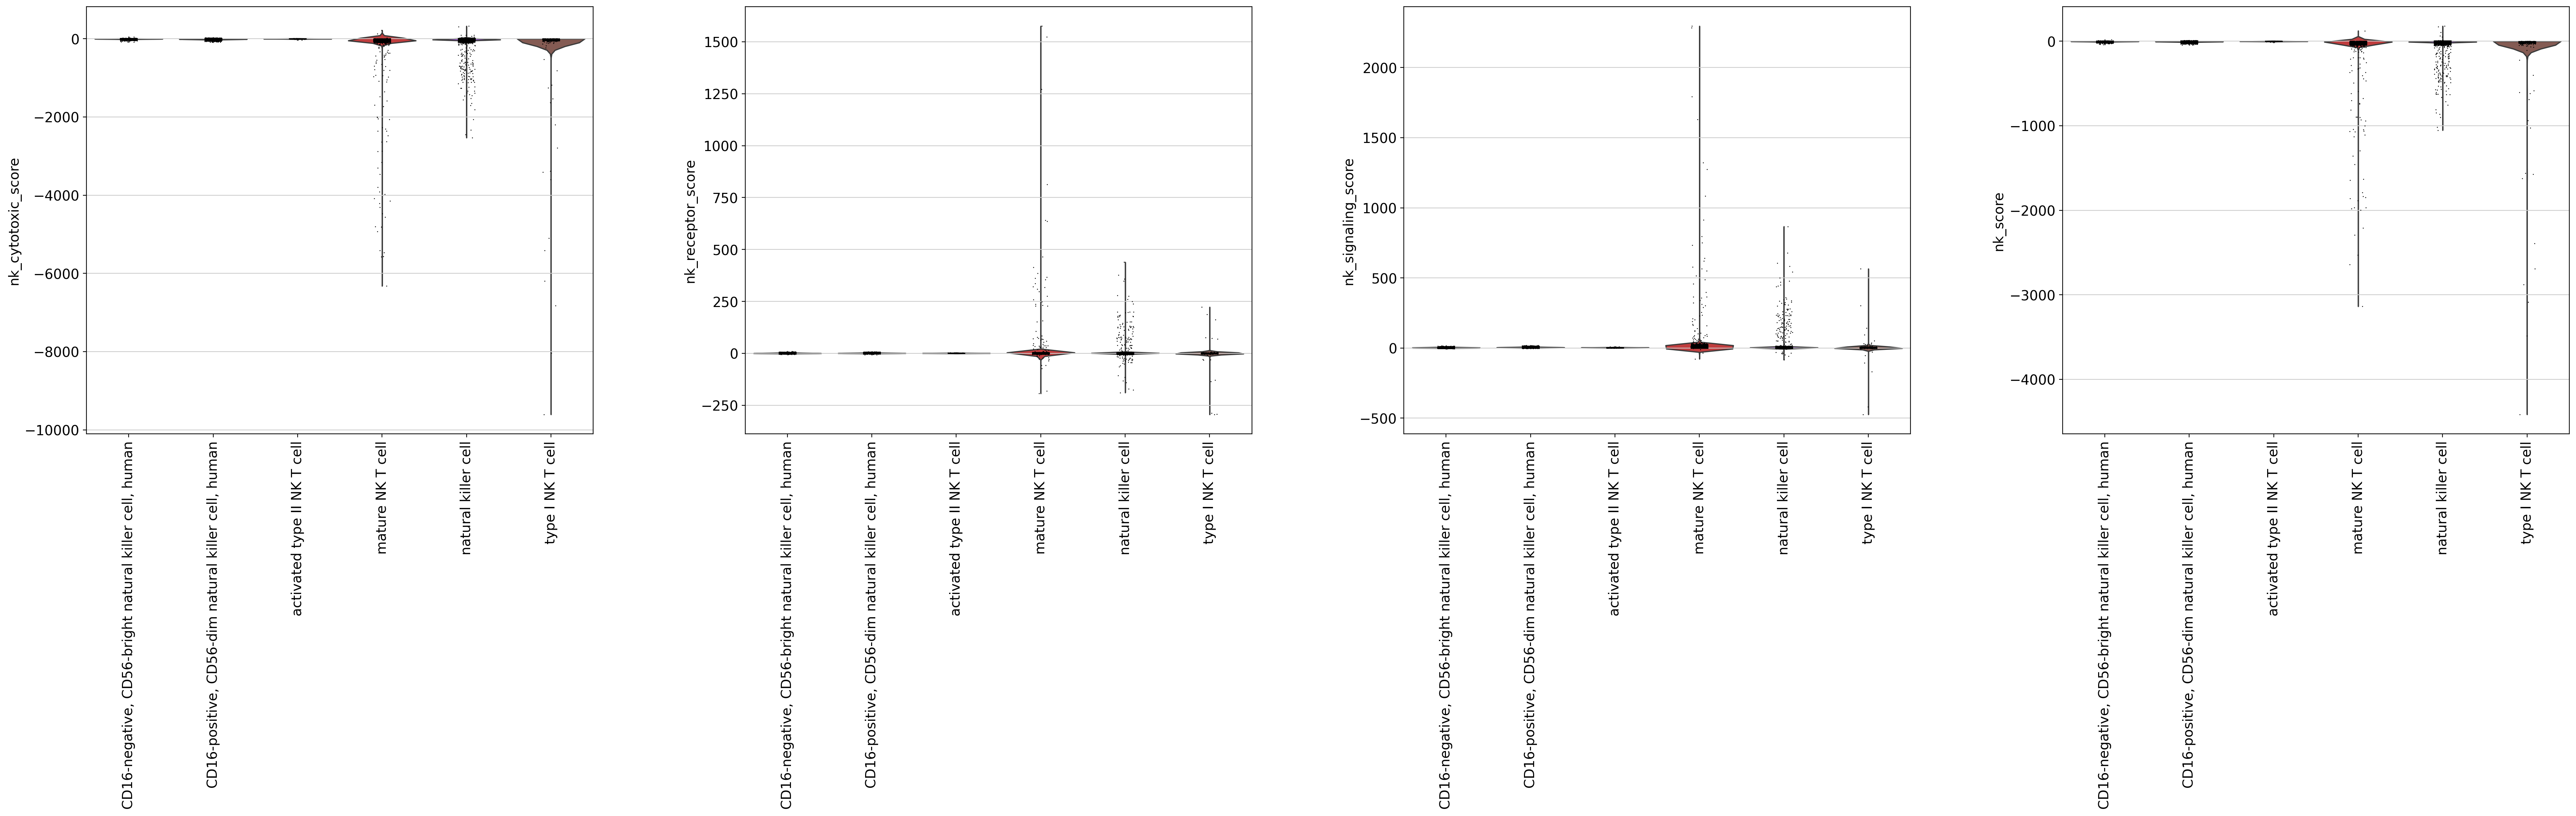

KeyError: "Could not find 'umap' or 'X_umap' in .obsm"

In [13]:
# Definir conjuntos de genes NK por categoría funcional
nk_cytotoxic_genes = ["NKG7", "GNLY", "PRF1", "GZMA", "GZMH", "GZMM"]
nk_receptor_genes = ["KLRD1", "KLRB1", "KLRF1", "KLRC1", "KLRK1", "NCR3"]
nk_signaling_genes = ["TYROBP", "HCST", "FCER1G", "CD247"]

# Calcular scores para cada conjunto de genes
sc.tl.score_genes(adata, nk_cytotoxic_genes, score_name='nk_cytotoxic_score', ctrl_size=len(nk_cytotoxic_genes))
sc.tl.score_genes(adata, nk_receptor_genes, score_name='nk_receptor_score', ctrl_size=len(nk_receptor_genes))
sc.tl.score_genes(adata, nk_signaling_genes, score_name='nk_signaling_score', ctrl_size=len(nk_signaling_genes))

# Calcular score global con todos los marcadores NK de alta confianza
high_confidence_nk_genes = [gene for gene, metrics in nk_markers.items() 
                            if metrics['effect_size'] > 1.0 and metrics['specificity'] > 0.95]
sc.tl.score_genes(adata, high_confidence_nk_genes, score_name='nk_score', 
                  ctrl_size=min(50, len(high_confidence_nk_genes)))

# Visualizar distribución de scores
sc.pl.violin(adata, ['nk_cytotoxic_score', 'nk_receptor_score', 'nk_signaling_score', 'nk_score'], 
             groupby='cell_type', rotation=90)

# Colorear UMAP por scores
sc.pl.umap(adata, color=['nk_cytotoxic_score', 'nk_receptor_score', 'nk_signaling_score', 'nk_score'])

In [14]:
import numpy as np
import pandas as pd
from scipy import stats

# Estadísticas básicas de los scores
score_stats = adata.obs[['nk_cytotoxic_score', 'nk_receptor_score', 'nk_signaling_score', 'nk_score']].describe()
print(score_stats)

# Definir un umbral basado en la distribución (por ejemplo, media - 1 desviación estándar)
nk_score_threshold = adata.obs['nk_score'].mean() - adata.obs['nk_score'].std()
print(f"Umbral de score NK: {nk_score_threshold:.4f}")

# Porcentaje de células que superan el umbral
pct_above_threshold = (adata.obs['nk_score'] > nk_score_threshold).mean() * 100
print(f"Porcentaje de células que superan el umbral: {pct_above_threshold:.2f}%")

       nk_cytotoxic_score  nk_receptor_score  nk_signaling_score  \
count       365362.000000      365362.000000       365362.000000   
mean           -12.744582           0.806098            3.419440   
std             52.627113           5.936984           10.166492   
min          -9605.409091        -293.833333         -473.500000   
25%            -16.636364           0.000000            1.500000   
50%            -10.090909           0.666667            3.000000   
75%             -5.651515           1.333333            4.500000   
max            322.136364        1575.166667         2295.750000   

            nk_score  
count  365362.000000  
mean       -5.560280  
std        23.181640  
min     -4415.108333  
25%        -7.383333  
50%        -4.241667  
75%        -2.216667  
max       178.500000  
Umbral de score NK: -28.7419
Porcentaje de células que superan el umbral: 99.66%


In [6]:
def calculate_nk_validation_score(adata, nk_markers):
    """
    Calcula un score de validación ponderado para células NK basado en DWLS
    
    Parameters:
    -----------
    adata : AnnData
        Objeto AnnData conteniendo los datos de expresión
    nk_markers : dict
        Diccionario con genes marcadores NK y sus métricas
        
    Returns:
    --------
    numpy.ndarray
        Array con los scores de validación NK para cada célula
    """
    genes_found = [gene for gene in nk_markers.keys() if gene in adata.var_names]
    
    # Inicializar score
    scores = np.zeros(adata.shape[0])
    weights_sum = 0
    
    for gene in genes_found:
        # Ponderación basada en DWLS: Effect Size × Specificity
        weight = nk_markers[gene]['effect_size'] * nk_markers[gene]['specificity']
        
        # Obtener expresión y multiplicar por peso
        expr = adata[:, gene].X.toarray().flatten()
        scores += expr * weight
        weights_sum += weight
    
    # Normalizar por la suma de pesos
    if weights_sum > 0:
        scores = scores / weights_sum
    
    return scores

In [5]:
# Filtrar células anotadas como NK
nk_cells = adata[adata.obs['cell_type'].str.contains('NK', case=False)].copy()

# Verificar la expresión de marcadores NK en estas células
def verify_marker_expression(adata, markers_dict, threshold_pct=0.6):
    """Verifica qué porcentaje de células expresan cada marcador por encima del umbral"""
    results = {}
    
    for gene, metrics in markers_dict.items():
        if gene not in adata.var_names:
            results[gene] = {'status': 'not_found', 'pct_cells_expressing': 0}
            continue
            
        # Calcular porcentaje de células que expresan el gen
        exp_matrix = adata[:, gene].X.toarray().flatten()
        pct_expressing = np.sum(exp_matrix > 0) / len(exp_matrix) * 100
        
        # Comparar con el valor esperado
        expected_pct = metrics['pct_cells']
        ratio = pct_expressing / expected_pct
        
        if ratio >= threshold_pct:
            status = 'validated'
        else:
            status = 'below_threshold'
            
        results[gene] = {
            'status': status,
            'pct_cells_expressing': pct_expressing,
            'expected_pct': expected_pct,
            'ratio': ratio
        }
    
    return results

validation_results = verify_marker_expression(nk_cells, nk_markers)

# Calcular métricas de validación
validated_markers = sum(1 for gene, result in validation_results.items() if result['status'] == 'validated')
total_markers = len(nk_markers)
validation_score = validated_markers / total_markers

print(f"Porcentaje de marcadores validados: {validation_score * 100:.2f}%")

Porcentaje de marcadores validados: 57.83%


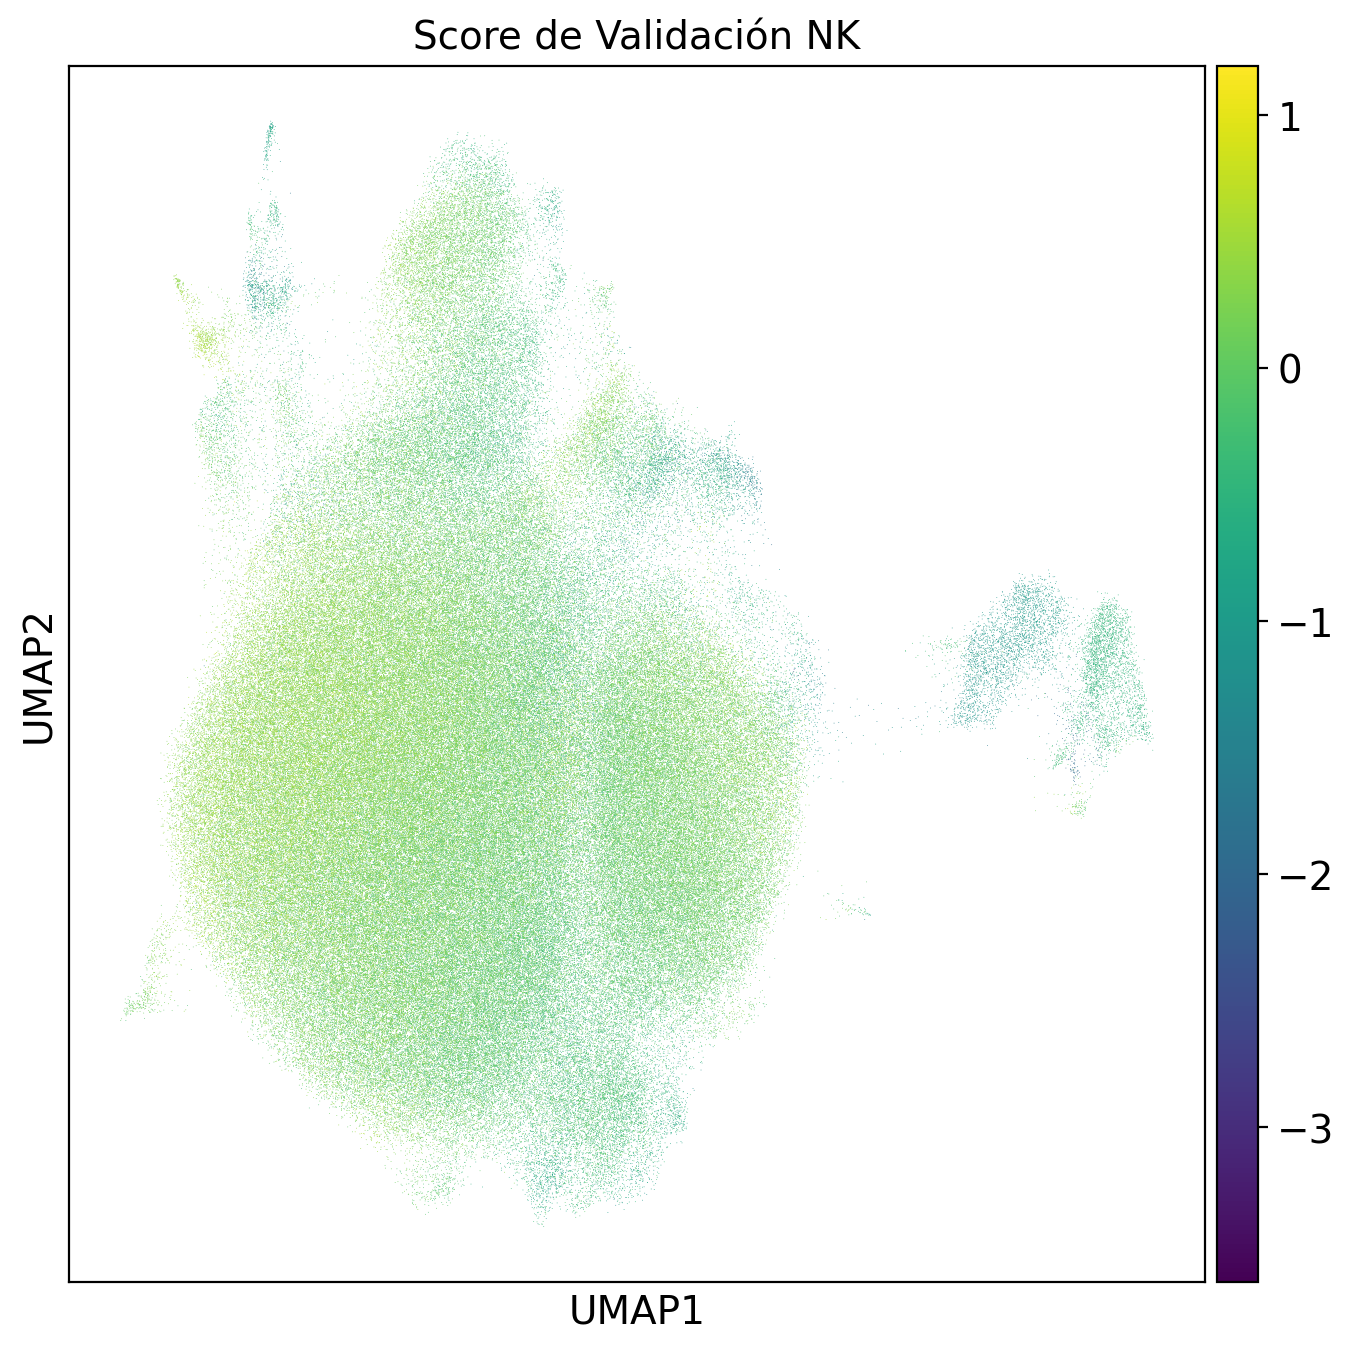

KeyError: "Could not find keys '['CD7', 'GZMA', 'NKG7']' in columns of `adata.obs` or in adata.raw.var_names."

In [6]:
# Visualizar la distribución del score de validación
sc.pl.umap(adata, color='nk_validation_score', title='Score de Validación NK')

# Visualizar expresión de marcadores core en células anotadas como NK
sc.pl.dotplot(nk_cells, var_names=core_markers, 
             groupby='cell_type', title='Expresión de Marcadores Core en Células NK')

# Crear heatmap de expresión de marcadores NK
sc.pl.heatmap(nk_cells, var_names=list(nk_markers.keys()), 
             groupby='cell_type', show_gene_labels=True,
             title='Expresión de Marcadores NK')

# Visualizar comparación entre valores esperados y observados
marker_names = list(validation_results.keys())
observed_pct = [result['pct_cells_expressing'] for result in validation_results.values()]
expected_pct = [result['expected_pct'] for result in validation_results.values()]

plt.figure(figsize=(12, 8))
x = np.arange(len(marker_names))
width = 0.35

plt.bar(x - width/2, expected_pct, width, label='% Esperado')
plt.bar(x + width/2, observed_pct, width, label='% Observado')

plt.xlabel('Marcadores NK')
plt.ylabel('% de Células')
plt.title('Comparación de Expresión de Marcadores NK: Esperado vs Observado')
plt.xticks(x, marker_names, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()